In [51]:
#created on 17/04/2026 by James McLoughlin

In [4]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import cartopy.crs as ccrs
import earthaccess
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
import rasterio as rio
from rasterio.enums import Resampling
from rasterio import features
from rasterio.features import shapes
from rasterio.features import sieve
import rasterio.merge
from rasterio.merge import merge
from rasterio.plot import show
from rasterstats import zonal_stats
import rioxarray
import shapely
from shapely.geometry import shape
from shapely.geometry import Polygon
from shapely import affinity
import xarray as xr
from xrspatial import hillshade



#from cartopy.crs import PlateCarree


In [49]:
# Dictionaries describing the bands of the landsat satellites and  
satbands = {
    "LT05":{"B1":"BLUE", "B2":"GREEN", "B3":"RED", "B4":"NIR", "B5":"SWIR1", "B7":"SWIR2"},
    "LT07":{"B1":"BLUE", "B2":"GREEN", "B3":"RED", "B4":"NIR", "B5":"SWIR1", "B6":"TIR", "B7":"SWIR2" },
    "LC08":{"B1":"COAST/AERO", "B2":"BLUE", "B3":"GREEN", "B4":"RED", "B5":"NIR", "B6":"SWIR1", "B7":"SWIR2"},
    "LC09":{"B1":"COAST/AERO", "B2":"BLUE", "B3":"GREEN", "B4":"RED", "B5":"NIR", "B6":"SWIR1", "B7":"SWIR2"}
}

index_to_bands = {
    "TRUE_COLOUR" : ["BLUE", "GREEN", "RED"],
    "FALSE_COLOUR" : ["GREEN","RED","NIR"],
    "NDVI": ["RED", "NIR"],
    "NDWI": ["GREEN", "NIR"],
    "NDSI": ["GREEN", "SWIR1"]
}

In [12]:
# User inputs
#userdevifens location of base (Parent) file
base = Path("C:/RS_GIS/EGM722/Assignment/Grand_Canyon/USGS_data/Unzipped")
boundary_file = "C:/RS_GIS/EGM722/Assignment/Grand_Canyon/shaprfiles/national_park_boundary.shp"
river_ref = "C:/RS_GIS/EGM722/Assignment/Grand_Canyon/shaprfiles/river.shp"

paths = {
    "ndi": base / "Processed_data" / "NDIs",
    "mosaics": base / "Processed_data" / "Mosaics",
    "masks": base / "Processed_data" / "Masks",
    "polygons": base / "Processed_data" / "Polygons",
    "earthaccess": base / "EarthAccess",
    "clipped": base / "Processed_data" / "Clipped Images"
}
for path in paths.values():
    path.mkdir(parents=True, exist_ok=True)
print('Directories created')

Directories created


In [52]:
## User selects desired processing:
user_choice = {
    "TRUE_COLOUR": 1,
    "FALSE_COLOUR": 0,
    "NDVI": 1,
    "NDWI": 1,
    "NDSI": 0,
}

display_tasks = [task for task in ["TRUE_COLOUR", "FALSE_COLOUR"] if user_choice.get(task)]
display_colours_raw = list({band for key in display_tasks for band in index_to_bands[key]}) #unique colours in set first
colour_order = ["COAST/AERO","BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2","PAN","CIRRUS","TIR1","TIR2"]
display_colours = [b for b in colour_order if b in display_colours_raw]

analysis_tasks = [task for task in ["NDVI", "NDWI", "NDSI"] if user_choice.get(task)]
analysis_colours = list({band for key in analysis_tasks for band in index_to_bands[key]})

all_colours = list(set(display_colours + analysis_colours))

In [25]:
#Building the dataframe of raw data files
def raster_dataframe(base_path, folder_name):
    print("Creating Landsat image dataFrame")
    base = Path(base_path)
    landsat_images = base / folder_name
    records = []
    for folder in landsat_images.iterdir():
        if folder.is_dir():
            for file in folder.glob("*_SR_B*.TIF"):
                parts = file.name.split("_")
                sat = parts[0]
                band = parts[-1].replace(".TIF", "")
                records.append({
                    "folder": folder.name,
                    "file": file.name,
                    "path": file,
                    "year": parts[3][:4],
                    "satellite": sat,
                    "path_row": parts[2],
                    "band": band,
                    "colour": satbands[sat][band]
                })
    raster_df = pd.DataFrame(records)
    df_filename = landsat_images / "Landsat_Image_Dataset.csv"
    raster_df.to_csv(df_filename, index=False)
    print("Landsat image dataFrame created")
    return raster_df

landsat_df = raster_dataframe(base, "Landsat_Images")

Creating Landsat image dataFrame
Landsat image dataFrame created


In [34]:
#Function to calculate NDI
def NDI_calculation(df, NDI):
    for yr in df["year"].unique():
    # def NDI_calculation(yr, pathrow, NDI, clipped):
        print("ND*I analysis started")
        for analysis in NDI:
            colr1 = index_to_bands[analysis][0]
            colr2 = index_to_bands[analysis][1]
            # if clipped == 0:
            #     path1 = df[(df["colour"] == colr1) & (df["year"] == yr) & (df["path_row"] == pathrow)]["path"].iloc[0]
            #     path2 = df[(df["colour"] == colr2) & (df["year"] == yr) & (df["path_row"] == pathrow)]["path"].iloc[0]
            # elif clipped == 1:
            path1 = paths["clipped"] / f"{yr}_{colr1}_clipped.tif"
            path2 = paths["clipped"] / f"{yr}_{colr2}_clipped.tif"
            
            with rio.open(path1) as src1, rio.open(path2) as src2:
                tile1 = src1.read(1).astype("float32")
                tile2 = src2.read(1).astype("float32")
                with np.errstate(invalid='ignore'):
                    ndi_img = (tile1 - tile2) / (tile1+tile2)
                ndi_img[np.isnan(ndi_img)] = -9999 
                ndi_out = paths["ndi"] / f"{yr}_{analysis}.tif"
                out_meta = src1.meta.copy()
                out_meta.update(dtype = "float32", nodata = -9999)
        
            with rio.open(ndi_out, "w", **out_meta) as dst:
                dst.write(ndi_img,1)
    
            print(f"{yr} {analysis} calcualted and saved")
        print("ND*I Analsyis completed")

NDI_calculation(landsat_df, analysis_tasks)

ND*I analysis started
2020 NDVI calcualted and saved
2020 NDWI calcualted and saved
ND*I Analsyis completed


In [14]:
outline = gpd.read_file(boundary_file).to_crs(epsg = 4326).union_all()
search_area = outline.minimum_rotated_rectangle
search_area = shapely.geometry.polygon.orient(search_area, sign=1)
#getting dem data from earthaccess
earthaccess.login(strategy='netrc')
results = earthaccess.search_data(
    short_name = 'ASTGTM',
    polygon = search_area.exterior.coords
)
output_folder = paths["earthaccess"]
download_file = earthaccess.download(results, output_folder)

QUEUEING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/16 [00:00<?, ?it/s]

In [15]:
# mosaic the DEMs
dem_files = [fn for fn in download_file if 'dem.tif' in fn.name]
dem_merged_path = paths["earthaccess"] / "DEM_merged.TIF"
rio.merge.merge(dem_files, dst_path=dem_merged_path, dtype = 'float32')
with rio.open(dem_merged_path) as dataset:
    dem = dataset.read(1)
    crs = dataset.crs
    xmin, ymin, xmax, ymax = dataset.bounds

In [18]:
### Clipping DEM mosiac
dem_file = paths["earthaccess"] / "DEM_merged.TIF"
rds = rioxarray.open_rasterio(dem_file)
gdf = gpd.read_file(boundary_file).to_crs(rds.rio.crs)
clipped = rds.rio.clip(gdf.geometry, gdf.crs, drop=True)
clipped_dem = paths["clipped"] / "clipped DEM.tif"
clipped.rio.to_raster(clipped_dem)

In [36]:
with rio.open(clipped_dem) as src:
    dem = src.read(1)
    meta = src.meta.copy()
    dem_clean = np.nan_to_num(dem, nan=-9999) #replace NaNs with -9999
    zones = (dem_clean // 500).astype(np.int32) #split elevtion range into 500m intervals. Floor divions used to crete discrete steps
    transform = src.transform
    crs = src.crs

polygons_list = [] # Create an empty list for elevation zone polygons

# Loop through the shapes found in the elevation zones and detemine geometry (s) and value (v)
for s, v in features.shapes(zones, transform=transform):
    if v != src.nodata:     #Skip areas of empty space
        
        # Build polygon dictionary in GeoPandas format and add to list
        feature_dict = {'properties': {'elev_zone': v}, 'geometry': s}
        polygons_list.append(feature_dict)

# Now turn that list into a GeoDataFrame
gdf_segments = gpd.GeoDataFrame.from_features(polygons_list, crs="EPSG:4326")
gdf_segments = gdf_segments.to_crs("EPSG:26912")

ndvi_path = paths["ndi"] / "2020_NDVI.tif" # path for NDVI image to be cmopared against segmented DEM
stats = zonal_stats(gdf_segments, str(ndvi_path), stats="mean", all_touched=True) # Runing zonal statistics on ndvi_path
gdf_segments['mean_ndvi'] = [s['mean'] for s in stats] # Attaching results to GeoDataFrame
gdf_results = gdf_segments.dropna(subset=['mean_ndvi']) # cleaning up empty or NoData zones



# # results = (
# #     {'properties': {'elev_zone': v}, 'geometry': s}
# #     for i, (s, v) in enumerate(features.shapes(zones, transform=transform))
# #     if v != src.nodata  # Ignore NoData areas
# # )

In [ ]:
#-----------------Plotting data

In [56]:
display_tasks[0]

'TRUE_COLOUR'

Saved: C:\RS_GIS\EGM722\Assignment\Grand_Canyon\USGS_data\Unzipped\Processed_data\Mosaics\2020_TRUE_COLOUR_composite.tif


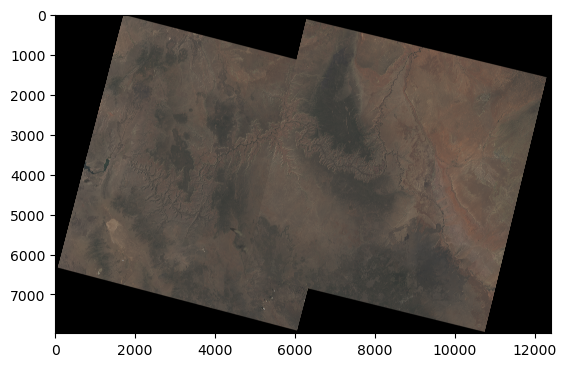

In [87]:
# creating composite images
def normalize(band):
    band_max, band_min = band.max(), band.min()
    norm = ((band - band_min)/(band_max - band_min))
    return norm
    
def composite_images(comp_types):
    for yr in landsat_df["year"].unique():
        for comp in comp_types:
            path1 = paths["mosaics"] / f"{yr}_{index_to_bands[comp][0]}_mosaic.tif"
            path2 = paths["mosaics"] / f"{yr}_{index_to_bands[comp][1]}_mosaic.tif"
            path3 = paths["mosaics"] / f"{yr}_{index_to_bands[comp][2]}_mosaic.tif"
    
        with rio.open(path1) as src1, rio.open(path2) as src2, rio.open(path3) as src3:
            colr1 = src1.read(1)
            colr2 = src2.read(1)
            colr3 = src3.read(1)
            out_meta = src1.meta.copy()
            ncolr1 = (normalize(colr1) * 255).astype(np.uint8)
            ncolr2 = (normalize(colr2) * 255).astype(np.uint8)
            ncolr3 = (normalize(colr3) * 255).astype(np.uint8)
            
            out_meta.update({
                "driver": "GTiff",
                "count": 3,
                "dtype": "uint8",
                "compress": "lzw"
            })
            out_filename = paths["mosaics"] / f"{yr}_{comp}_composite.tif"

            with rio.open(out_filename, 'w', **out_meta) as dst:
                dst.write(ncolr3, 1) # Red channel (or first selected band)
                dst.write(ncolr2, 2) # Green channel
                dst.write(ncolr1, 3) # Blue channel
                
            print(f"Saved: {out_filename}")
composite_images(display_tasks)

In [73]:
dem_path = paths["earthaccess"] / "DEM_merged.TIF"
with rio.open(dem_path) as src:
    dem = src.read(1)
    out_meta = src.meta.copy()
elevation_da = xr.DataArray(dem, dims=['y', 'x'])
illuminated = hillshade(elevation_da, azimuth=315, angle_altitude=45)
out_filename = paths["mosaics"] / "hillshade.tif"
with rio.open(out_filename, 'w', **out_meta) as dst:
    dst.write(illuminated, 1)
print('data saved')                
#plt.imshow(illuminated, cmap='Greys')
#plt.show

data saved


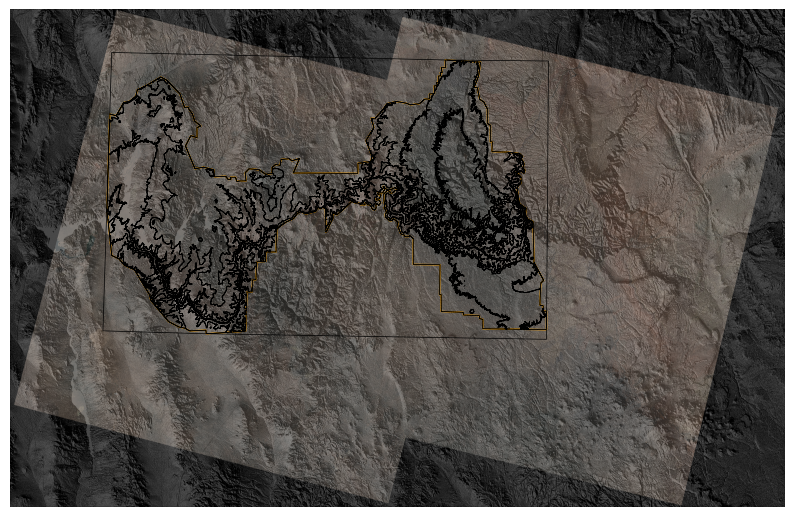

In [99]:
#Plotting results

comp_path = paths["mosaics"] / "2020_TRUE_COLOUR_composite.tif"
hill_path = paths["mosaics"] / "hillshade.tif"
boundary = gpd.read_file(boundary_file)

with rio.open(comp_path) as src:
    img_extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    rgb_composite = src.read([1,2,3]).transpose(1,2,0)/255
    
boundary = boundary.to_crs(src.crs)
gdf_results = gdf_results.to_crs(src.crs)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(rgb_composite, extent=img_extent)
ax.imshow(hillshade, cmap='gray', alpha=0.4, extent=img_extent)
boundary.plot(ax=ax, facecolor='none', edgecolor='orange', linecolor='orange', linewidth=1)
gdf_results.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5)

ax.set_axis_off()
plt.show()



#     fig.colorbar(ax.get_images()[0], ax=ax, label='NDVI Value')

In [157]:
def mosaicking(df, colour_bands):
    print("Mosaicking started")
    for yr in df["year"].unique():
        for colr in colour_bands:
            file_list = df[(df["year"] == yr) & (df["colour"] == colr)]["path"].tolist()
            mosaic_out = dirs["mosaics"] / f"{yr}_{colr}_mosaic.tif" 
            rio.merge.merge(file_list, dst_path = mosaic_out)
            print(f"{yr} {colr} band mosaic created and saved")    
    print("Mosaicking completed")

In [168]:
### Clipping rasters
def clipping(df, colour_bands, ref_poly):
    print("Image clipping started")
    for yr in df["year"].unique():
        for colr in colour_bands:
            scene = dirs["mosaics"] / f"{yr}_{colr}_mosaic.tif"
            # landsat_scene = df[(df["colour"] == colr) & (df["year"] == yr) & (df["path_row"] == pathrow)]["path"].iloc[0]
            rds = rioxarray.open_rasterio(scene)
            gdf = gpd.read_file(ref_poly).to_crs(rds.rio.crs)
            clipped = rds.rio.clip(gdf.geometry, gdf.crs, drop=True)
            clipped_out = dirs["clipped"] / f"{yr}_{colr}_clipped.tif"
            clipped.rio.to_raster(clipped_out)
            print(f"{yr} {colr} mosaic clipped and saved") 
    print("All clippling completed")

In [150]:
# ### Clipping rasters
# def clipping(idx_tsk, ref_poly):
#     print("Image clipping started")
#     for yr in df["year"].unique():
#         for idx in idx_tsk:
#             landsat_scene = dirs["mosaics"] / f"{yr}_{colr}_mosaic.tif"
#             # landsat_scene = df[(df["colour"] == colr) & (df["year"] == yr) & (df["path_row"] == pathrow)]["path"].iloc[0]
#             rds = rioxarray.open_rasterio(landsat_scene)
#             gdf = gpd.read_file(ref_poly).to_crs(rds.rio.crs)
#             clipped = rds.rio.clip(gdf.geometry, gdf.crs, drop=True)
#             clipped_out = clipped_images / f"{yr}_{colr}_clipped.tif"
#             clipped.rio.to_raster(clipped_out)
#             print(f"{yr} {colr} mosaic clipped and saved") 
#     print("All clippling completed")

In [ ]:
#dirs = create_directories(parent);
#landsat_df = raster_dataframe(parent, "Landsat_Images")
#landsat_df.head()
#mosaicking(landsat_df, all_colours)
#clipping(landsat_df, analysis_colours, park_boundary)
print(analysis_tasks)
analysis_tasks = ['NDVI', 'NDWI']
NDI_calculation(analysis_tasks)


#acquire_earthacess_data(park_boundary)

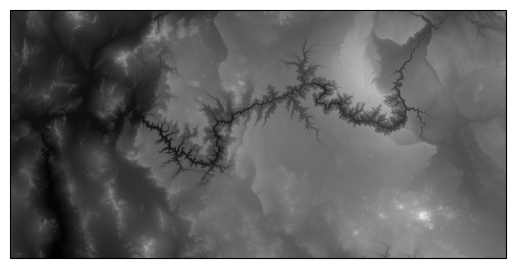

In [61]:
# Plots the mosaicked DEM layer
#data_crs=ccrs.PlateCarree()
fig, ax = plt.subplots(1, 1, subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.imshow(dem, cmap='gray', transform=ccrs.PlateCarree(), extent=[xmin, xmax, ymin, ymax]) # display band 0 as a grayscale image, stretched between 0 and 400
ax.set_extent([xmin, xmax, ymin, ymax], crs=ccrs.PlateCarree())
plt.show()

In [ ]:
# #for yr in df["year"].unique():
# #    for pr in df["path_row"].unique():
# create_directories(base)

# mosaicking(unique_bands)
# input_file = 
# clipping(input_file, park_ref_out)
# #         clipping(yr,"NDVI", park_ref_out)
# # #        NDI_calculation(yr, pr, 'NDWI')
# #         NDI_calculation(yr, 'NDVI')
# # #        mask_segment = mask_from_raster(yr, pr, 'NDWI')
# # #        all_polygons.append(mask_segment.to_crs("EPSG:26912"))

# # #merging_polygons(all_polygons, river_ref)

In [5]:
# 
#Function to calculate NDI
# def NDI_calculation(yr, pathrow, NDI, clipped):
#     colr1 = index_to_bands[NDI][0]
#     colr2 = index_to_bands[NDI][1]
#     if clipped == 0:
#         path1 = df[(df["colour"] == colr1) & (df["year"] == yr) & (df["path_row"] == pathrow)]["path"].iloc[0]
#         path2 = df[(df["colour"] == colr2) & (df["year"] == yr) & (df["path_row"] == pathrow)]["path"].iloc[0]
#     elif clipped == 1:
#         path1 = clipped_images / f"{yr}_{pr}_{colr1}_clipped.tif"
#         path2 = clipped_images / f"{yr}_{pr}_{colr2}_clipped.tif"
    
#     with rio.open(path1) as src1, rio.open(path2) as src2:
#         tile1 = src1.read(1).astype("float32")
#         tile2 = src2.read(1).astype("float32")
#         with np.errstate(invalid='ignore'):
#             ndi_img = (tile1 - tile2) / (tile1+tile2)
#         ndi_img[np.isnan(ndi_img)] = -9999 
##         if clipped == 0:
##             ndi_out = NDI_data / f"{yr}_{pathrow}_{NDI}.tif"
##         elif clipped == 1:
#             ndi_out = NDI_data / f"{yr}_{pathrow}_{NDI}.tif"
#         out_meta = src1.meta.copy()
#         out_meta.update(dtype = "float32", nodata = -9999)

#     with rio.open(ndi_out, "w", **out_meta) as dst:
#         dst.write(ndi_img,1)

In [16]:
# # creting bounding box for earth access search
# #boundary_file = polygon_data / "Grand_Canyon_River_Master.gpkg"
# boundary_file = polygons / "buffered_park_polygon.gpkg"
# outline = gpd.read_file(boundary_file).to_crs(epsg = 4326).union_all()
# search_area = outline.minimum_rotated_rectangle
# search_area = shapely.geometry.polygon.orient(search_area, sign=1)
# #getting dem data from earthaccess
# earthaccess.login(strategy='netrc')
# results = earthaccess.search_data(
#     short_name = 'ASTGTM',
#     polygon = search_area.exterior.coords
# )
# download_file = earthaccess.download(results, earthaccess_data)

C:\Users\jj_mc\anaconda3\envs\EGM722-Assessment\Lib\site-packages\earthaccess\results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
C:\Users\jj_mc\anaconda3\envs\EGM722-Assessment\Lib\site-packages\earthaccess\store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/16 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/16 [00:00<?, ?it/s]

In [11]:
# adding buffer to park boundary to avoid clipping river only
all_polygons = []
park_poly_file = "C:/RS_GIS/EGM722/Assignment/Grand_Canyon/shaprfiles/national_park_boundary.shp"
park_poly = gpd.read_file(park_poly_file).to_crs(epsg = 26912).union_all()
park_ploy_buffered = park_poly.buffer(1000)
park_buff_gdf = gpd.GeoDataFrame(geometry=[park_ploy_buffered],crs=('EPSG:26912'))
park_ref_out = polygons / "buffered_park_polygon.gpkg"
park_buff_gdf.to_file(park_ref_out, driver ="GPKG")

In [36]:
#function for isolationg and joing the river polygons
def merging_polygons(poly_gdf, ref_poly):
    combined_gdf = pd.concat(poly_gdf)
    
    #Apply buffer to bridge gaps between tiles
    combined_gdf['geometry'] = combined_gdf.geometry.buffer(100) 
    
    #Weld small localised pieces together
    merged = combined_gdf.union_all()
    
    # Searate main bodies into distinct polygons
    main_polygons = gpd.GeoSeries([merged], crs="EPSG:26912").explode(index_parts=False)
    main_polygons_gdf = gpd.GeoDataFrame(geometry=main_polygons)
   
    # Keep only polygons that touch river reference
    # ensures small 'ilsnad' polyons in the river path are not omitted.
    ref_geom = gpd.read_file(ref_poly).to_crs("EPSG:26912").union_all()
    referenced_poly = main_polygons_gdf[main_polygons_gdf.intersects(ref_geom)]
   
    # 5. Shrink it back (undo the buffer) to get original river width
    referenced_poly['geometry'] = referenced_poly.geometry.buffer(-100)
    buffered_poly = referenced_poly.copy()
    buffered_poly['geometry'] = buffered_poly.geometry.buffer(5000)

    poly_out = polygon_data / "Grand_Canyon_River.gpkg"
    buff_out = polygon_data / "Grand_Canyon_River_Buffer_5000.gpkg"
    referenced_poly.to_file(poly_out, driver="GPKG")
    buffered_poly.to_file(buff_out, driver="GPKG")

In [9]:
### function for making mask, binarising it, and converting to polygons
def mask_from_raster(year, pathrow, NDI):#, river_ref_path):
    poly_list = []
    file = NDI_data/f"{year}_{pathrow}_{NDI}.tif"
    with rio.open(file) as src:
        non_binary = src.read(1)
        mask = np.where(non_binary > -0.1 , 255 ,0).astype("uint8")
        cleaned_mask = sieve(mask,50)
        out_meta = src.meta.copy()
        out_meta.update(dtype = "uint8", nodata = 0)
        mask_out = masks / f"{year}_{pathrow}_{NDI}.tif"
        
        with rio.open(mask_out, "w", **out_meta) as dst:
            dst.write(cleaned_mask,1)

    file = mask_data / f"{year}_{pathrow}_{NDI}.tif"
    with rio.open(file) as src:
        tile = src.read(1).astype("int16")
        out_meta = src.meta.copy()
        mask_shapes = features.shapes(
            tile,
            mask = tile > 0,
            transform = out_meta['transform']
        )
    # The corrected list comprehension
    polygons = [
    {'geometry':shape(s),'properties':{'id': i}}
     for i, (s,v) in enumerate(mask_shapes)
    ]
              
    gdf = gpd.GeoDataFrame.from_features(polygons, crs=out_meta['crs'])
    return gdf

In [ ]:
# mosaic the DEMs


rio.merge.merge(dem_files, dst_path=dem_merged_path, dtype = 'float32')
with rio.open(dem_merged_path) as dataset:
    dem = dataset.read(1)
    crs = dataset.crs
    xmin, ymin, xmax, ymax = dataset.bounds

In [ ]:
def mosaicking(df, colour_bands):

    
            
            rio.merge.merge(file_list, dst_path = mosaic_out)
            print(f"{yr} {colr} band mosaic created and saved")    
    print("Mosaicking completed")

In [ ]:
### Clipping rasters
def clipping(df, colour_bands, ref_poly):
    print("Image clipping started")
    for yr in df["year"].unique():
        for colr in colour_bands:
            scene = dirs["mosaics"] / f"{yr}_{colr}_mosaic.tif"
            # landsat_scene = df[(df["colour"] == colr) & (df["year"] == yr) & (df["path_row"] == pathrow)]["path"].iloc[0]
            rds = rioxarray.open_rasterio(scene)
            gdf = gpd.read_file(ref_poly).to_crs(rds.rio.crs)
            clipped = rds.rio.clip(gdf.geometry, gdf.crs, drop=True)
            clipped_out = dirs["clipped"] / f"{yr}_{colr}_clipped.tif"
            clipped.rio.to_raster(clipped_out)
            print(f"{yr} {colr} mosaic clipped and saved") 
    print("All clippling completed")

In [ ]:
### Clipping DEM mosiac
dem_file = paths["earthaccess"] / "DEM_merged.TIF"
rds = rioxarray.open_rasterio(dem_file)
gdf = gpd.read_file(boundary_file).to_crs(rds.rio.crs)
clipped = rds.rio.clip(gdf.geometry, gdf.crs, drop=True)
clipped_dem = paths["clipped"] / "clipped DEM.tif"
clipped.rio.to_raster(clipped_dem)